In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import random
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import cross_val_predict
from sklearn.svm import SVC
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from palmerpenguins import load_penguins
#import graphviz
#from sklearn.tree import convert_to_graphviz


%matplotlib inline
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('ggplot')

# SVM
#### Usado principalmente para clasificación (aunque también se adapta a regresión). 
#### Su objetivo es encontrar el **hiperplano óptimo** que separa las clases de datos en el espacio de características, maximizando la distancia entre los datos de ambas clases y el hiperplano.

## ¿Por qué MAXIMIZAR la distancia entre los vectores de soporte con el hiperplano? 

En resumen, porque eso mejora la capacidad del modelo para generalizar a nuevos datos.
- Un margen más grande = más tolerancia al ruido.
- Generalizar, evitar overfitting



## Conceptos adicionales:

#### La idea es calcular todas las distancias entre los datos y el hiperplano. El mejor hiperplano es el que tiene un mayor **margen**, es decir, que la distancia mínima entre el hiperplano y las observaciones es lo más grande posible. 

#### Además del margen, existe un parámetro llamado C que funciona como un castigo o penalización por errores de clasificación. 
#### El C, nos permite encontrar un balance entre un margen grande y pocos errores.
#### C bajo: riesgo más alto (permite más errores, margen más ancho) y con mayor riesgo de underfitting.
#### C alto: Penaliza errores fuertemente (margen más estrecho), riesgo de overfitting. 


## Kernels
- El kernel es una función matemática que permite a un modelo SVM resolver problemas no lineales sin tener que transformar los datos explícitamente a un espacio de mayor dimensión.
- Más conocido como hacer "trampita matemática" para trabajar en un espacio más complejo sin tener que calcularlo directamente.

#### Ventajas:
- Resolver problemas no lineales sin transformar los datos explícitamente.
- Ahorro computacional: no necesitamos calcular vectores en espacios grandes, solo sus productos escalares.
- Flexibilidad: puedes adaptar el kernel a la geometría de tus datos.

#### Tipos: 
- Lineal (más usado): No transforma nada; igual que regresión
- Polinomial (común): Mapea data a espacios polinomiales
- RBF / Gausiano (común): Mapea la data a infinitas dimensiones
- Sigmoide (Inspirado para RN)

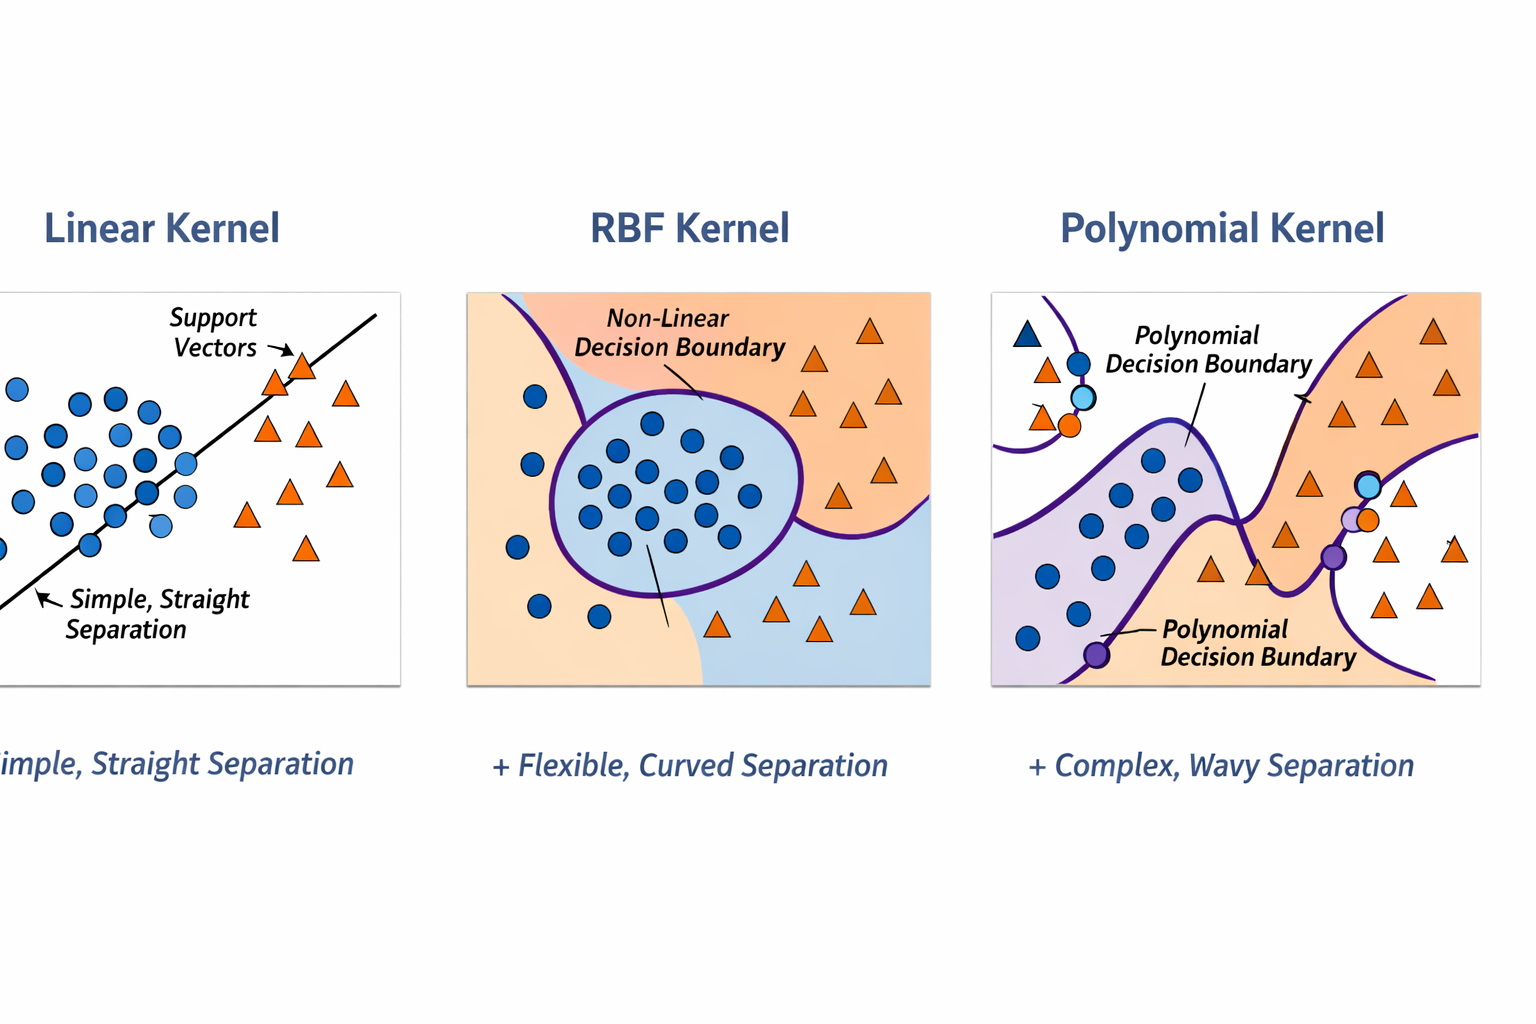

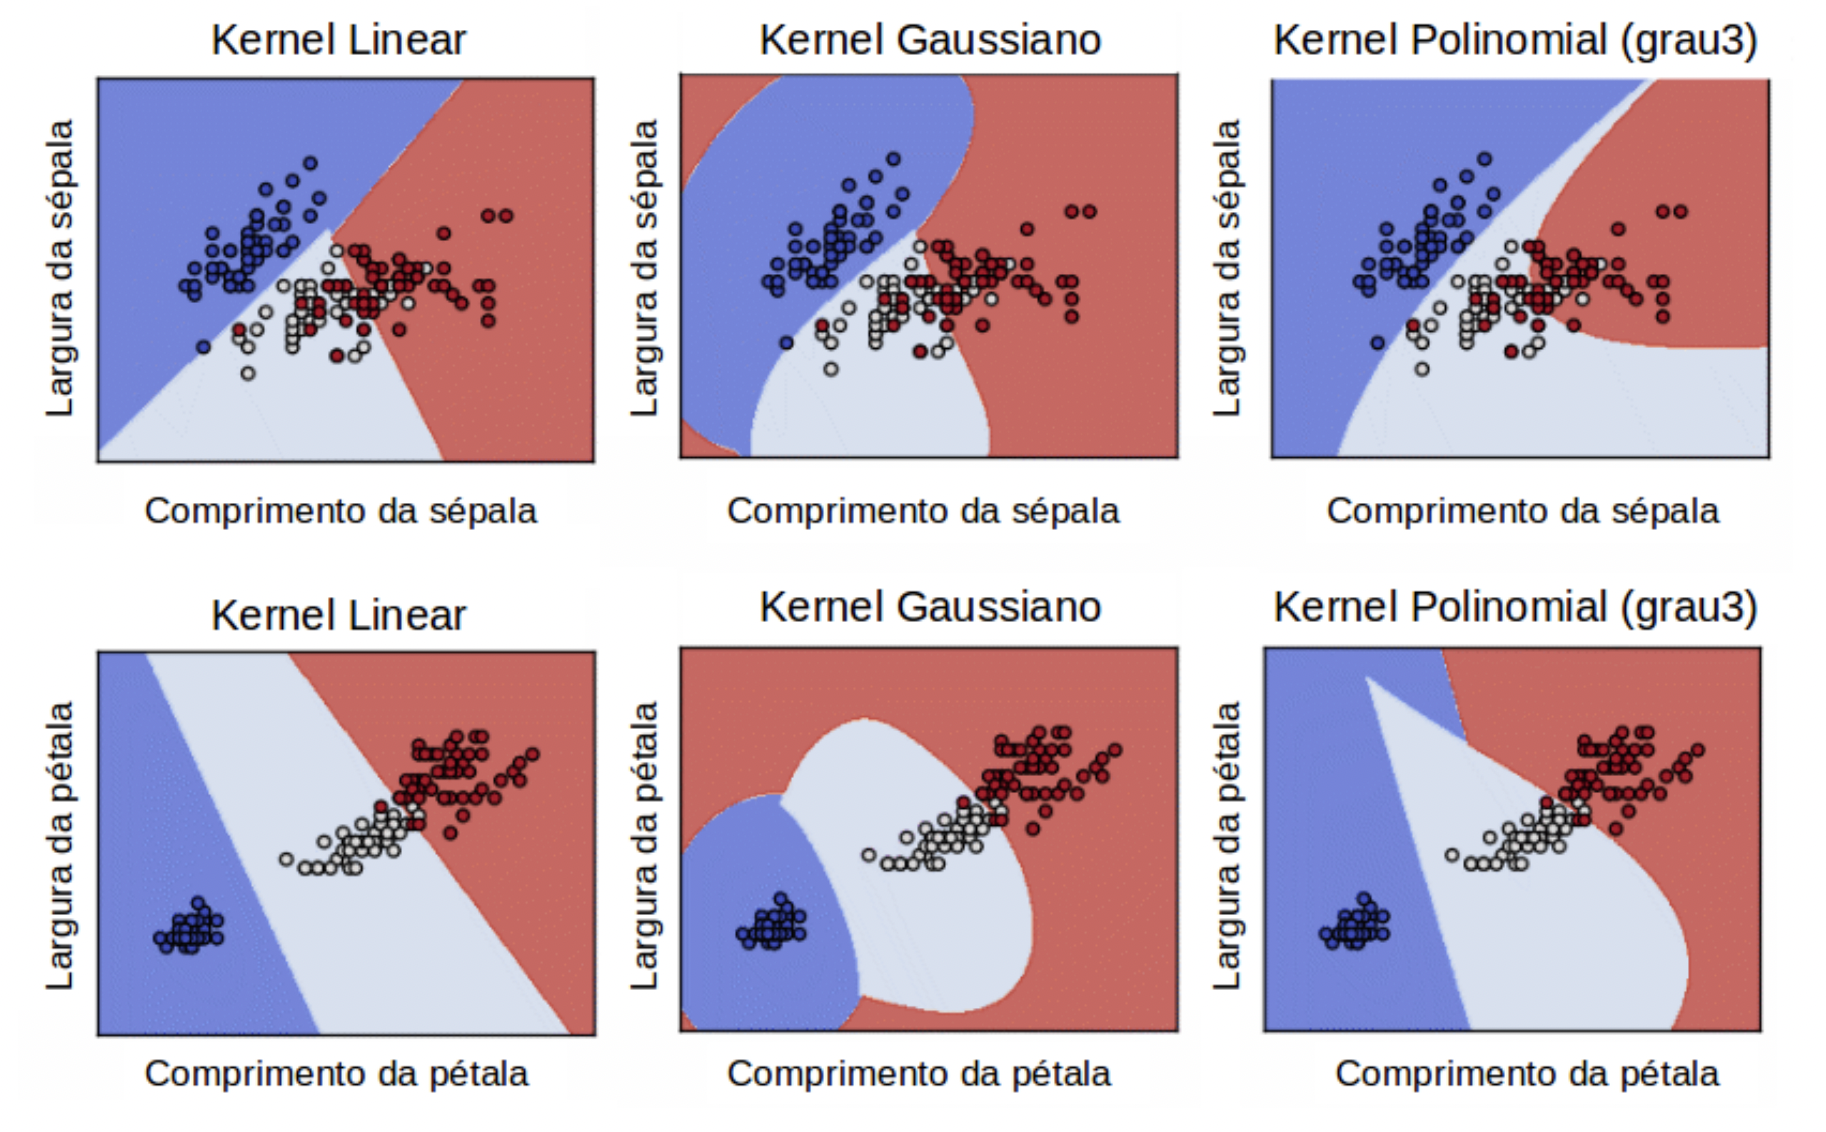

## Variables
- Variables de Entrada (X):
    - Acepta variables numéricas (reales). Si tienes categóricas, deben transformarse (por ejemplo, con one-hot encoding).
    - Puede funcionar con variables continuas o discretas.

- Variable Objetivo (y):
    - Para clasificación binaria: dos clases (ej. 0 y 1).
    - Para clasificación multiclase: con técnicas como "uno vs. resto".
    - En regresión: valores numéricos continuos.

| Aspecto                     | Regresión Logística         | SVM (sin calibración)                   |
|-----------------------------|-----------------------------|-----------------------------------------|
| Salida directa              | Probabilidad                | Score de distancia                      |
| Requiere calibración extra | No                          | Sí (para obtener probabilidades)        |
| Línea de decisión           | Basada en log-odds          | Hiperplano con margen                   |
| Interpretabilidad           | Alta (coeficientes)         | Baja (solo vectores soporte)            |


## Cargando el conjunto de datos
Cargaremos el conjunto de datos para explorarlo. 

In [5]:
df_pinguinos = load_penguins()
df_pinguinos.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


| Variable            | Significado                                                                 |
|---------------------|------------------------------------------------------------------------------|
| `species`           | Especie del pingüino (`Adelie`, `Chinstrap`, `Gentoo`)                      |
| `island`            | Isla donde fue encontrado el pingüino (`Biscoe`, `Dream`, `Torgersen`)      |
| `bill_length_mm`    | Longitud del pico en milímetros                                              |
| `bill_depth_mm`     | Profundidad del pico en milímetros                                           |
| `flipper_length_mm` | Longitud de la aleta en milímetros                                           |
| `body_mass_g`       | Masa corporal en gramos                                                      |
| `sex`               | Sexo del pingüino (`male`, `female`)                                         |
| `year`              | Año en que se tomó la observación (2007, 2008 o 2009)                        |


In [3]:
df_pinguinos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 21.6+ KB


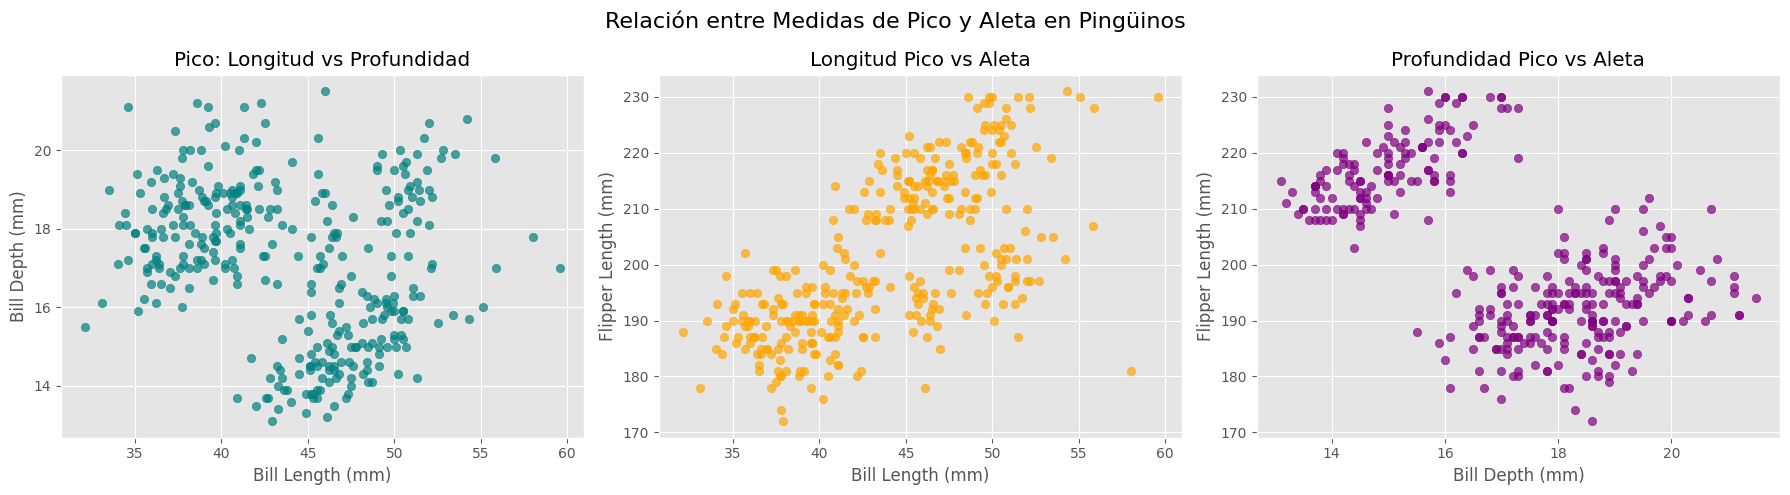

In [7]:
# Exploración básica
df = df_pinguinos.dropna(subset=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm'])

# Crear figura y subgráficos
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Relación entre Medidas de Pico y Aleta en Pingüinos', fontsize=16)

# Gráfico 1: Longitud vs profundidad del pico
axs[0].scatter(df['bill_length_mm'], df['bill_depth_mm'], c='teal', alpha=0.7)
axs[0].set_xlabel('Bill Length (mm)')
axs[0].set_ylabel('Bill Depth (mm)')
axs[0].set_title('Pico: Longitud vs Profundidad')

# Gráfico 2: Longitud del pico vs longitud de la aleta
axs[1].scatter(df['bill_length_mm'], df['flipper_length_mm'], c='orange', alpha=0.7)
axs[1].set_xlabel('Bill Length (mm)')
axs[1].set_ylabel('Flipper Length (mm)')
axs[1].set_title('Longitud Pico vs Aleta')

# Gráfico 3: Profundidad del pico vs longitud de la aleta
axs[2].scatter(df['bill_depth_mm'], df['flipper_length_mm'], c='purple', alpha=0.7)
axs[2].set_xlabel('Bill Depth (mm)')
axs[2].set_ylabel('Flipper Length (mm)')
axs[2].set_title('Profundidad Pico vs Aleta')

plt.tight_layout()
plt.show()

Ahora con species (nuestra futura variable respuesta)

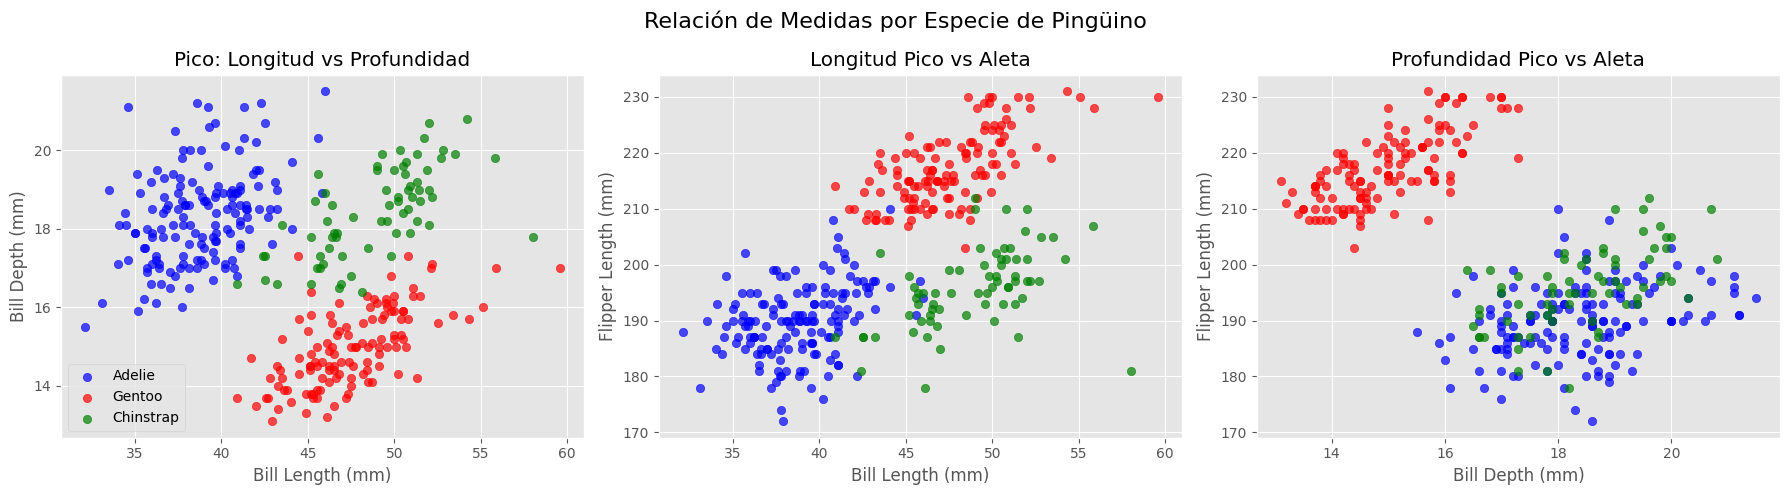

In [8]:
df = df_pinguinos.dropna(subset=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'species'])

# Asignar colores a cada especie
species_colors = {
    'Adelie': 'blue',
    'Chinstrap': 'green',
    'Gentoo': 'red'
}

# Crear figura y subgráficos
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Relación de Medidas por Especie de Pingüino', fontsize=16)

# Gráfico 1: Longitud vs profundidad del pico
for species in df['species'].unique():
    subset = df[df['species'] == species]
    axs[0].scatter(subset['bill_length_mm'], subset['bill_depth_mm'],
                   label=species, color=species_colors[species], alpha=0.7)
axs[0].set_xlabel('Bill Length (mm)')
axs[0].set_ylabel('Bill Depth (mm)')
axs[0].set_title('Pico: Longitud vs Profundidad')
axs[0].legend()

# Gráfico 2: Longitud del pico vs longitud de la aleta
for species in df['species'].unique():
    subset = df[df['species'] == species]
    axs[1].scatter(subset['bill_length_mm'], subset['flipper_length_mm'],
                   label=species, color=species_colors[species], alpha=0.7)
axs[1].set_xlabel('Bill Length (mm)')
axs[1].set_ylabel('Flipper Length (mm)')
axs[1].set_title('Longitud Pico vs Aleta')

# Gráfico 3: Profundidad del pico vs longitud de la aleta
for species in df['species'].unique():
    subset = df[df['species'] == species]
    axs[2].scatter(subset['bill_depth_mm'], subset['flipper_length_mm'],
                   label=species, color=species_colors[species], alpha=0.7)
axs[2].set_xlabel('Bill Depth (mm)')
axs[2].set_ylabel('Flipper Length (mm)')
axs[2].set_title('Profundidad Pico vs Aleta')

plt.tight_layout()
plt.show()

El conjunto de datos está compuesto por 344 filas y 8 variables.

In [11]:
df_pinguinos.shape

(344, 8)

A continuación veremos como están distribuidas las variables del conjunto de datos.

In [12]:
df_pinguinos.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,5.459584,1.974793,14.061714,801.954536,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


Las variables numéricas se encuentran en diferentes escalas, por lo que valdría la pena normalizarlas antes de usar un algoritmo.
Veamos ahora como están relacionadas algunas variables categóricas con las numéricas

Text(0, 0.5, 'Body Mass')

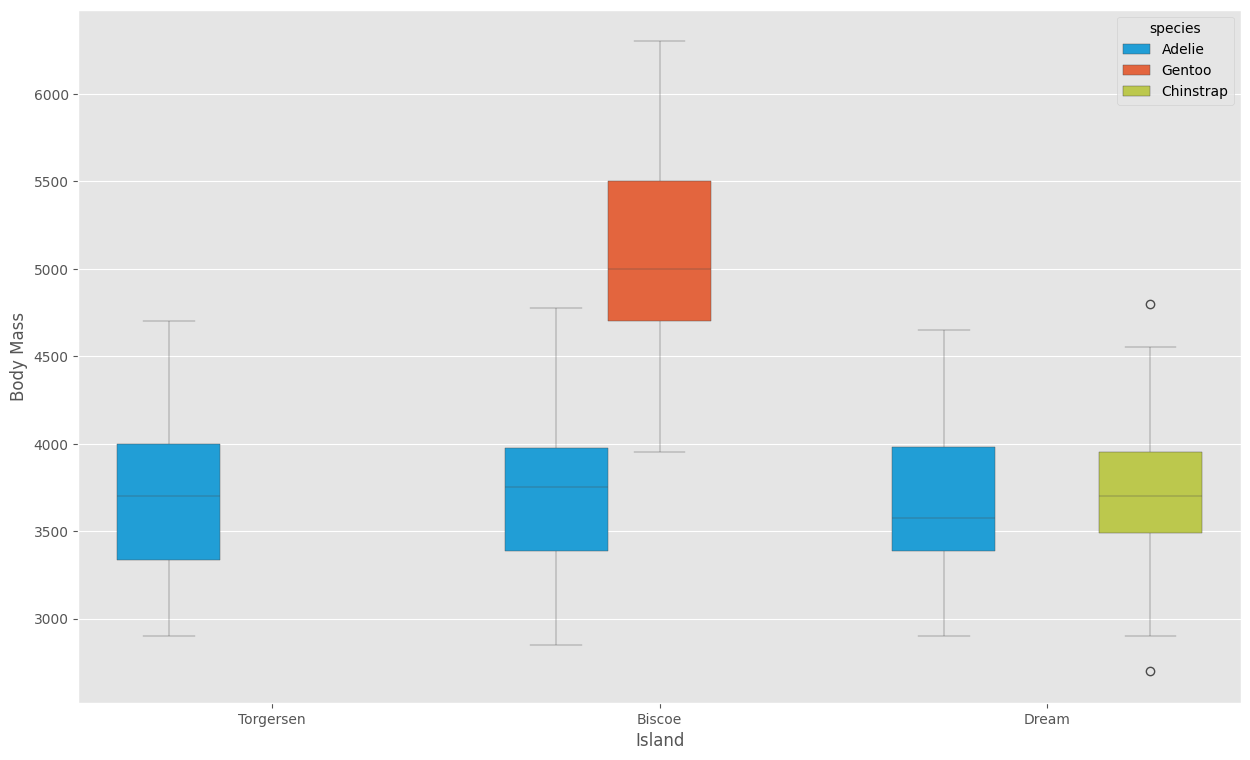

In [13]:
g = sb.boxplot(x = 'island',
            y ='body_mass_g',
            hue = 'species',
            data = df_pinguinos,
            palette=['#03A9F4','#FF5722','#CDDC39'],
            linewidth=0.3)
g.set_xlabel('Island')
g.set_ylabel('Body Mass')

Podemos observar que la especie Adelie está en las 3 islas mientras que las especies Gentoo y Ghinstrap están en las islas Biscoe y Dream respectivamente. La masa de los Gentoo es superior a todas las especies. Los Adelie son similares en la masa corporal no importa en la isla en la que habiten.

### Variable respuesta
La variable respuesta es la especie del pinguino, veamos que tan balanceado está nuesto conjunto de datos

In [14]:
df_pinguinos.groupby('species').size()

species
Adelie       152
Chinstrap     68
Gentoo       124
dtype: int64

<Axes: xlabel='Especie', ylabel='Cantidad'>

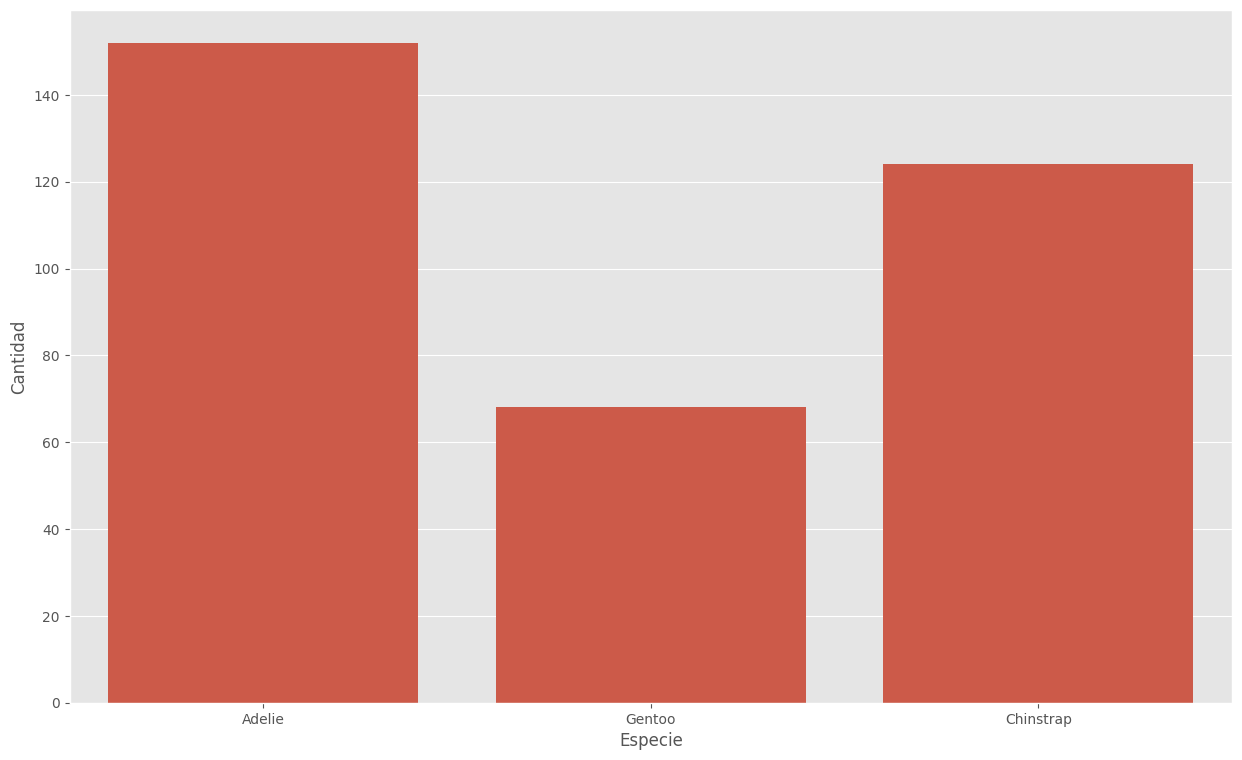

In [15]:
diccEspecie = {'Especie': df_pinguinos['species'].unique(), 'Cantidad': df_pinguinos.groupby('species').size()}
tbl_Specie = pd.DataFrame(diccEspecie)
sb.barplot(x="Especie",y="Cantidad", data=tbl_Specie)

<!-- Como se puede ver la variable respuesta no está del todo balanceada. Miremos las demas variables -->

## Algoritmo de Clasificación   
Se va a probar un algoritmo de máquinas vectoriales de soporte para clasificar un pinguino según la especie. 
Para esto vamos a dividir en conjuntos de entrenamiento (70%) y prueba (30%) los datos

In [9]:
target = df_pinguinos.pop('species')
data = df_pinguinos


In [10]:
random.seed(123)
data_train, data_test,target_train, target_test = train_test_split(data, target,test_size=0.3,train_size=0.7)
data_train.columns

Index(['island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm',
       'body_mass_g', 'sex', 'year'],
      dtype='object')

Separación de variables (categóricas vs numéricas)

In [11]:
nombre_categoricas = ['island','sex']
nombre_numericas = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm',
       'body_mass_g','year']
categoricas = data[nombre_categoricas]
numericas = data[nombre_numericas]

from sklearn.impute import SimpleImputer


### Preprocesamiento
Vamos a preprocesar las variables numéricas de forma diferente a las variables categóricas, las numéricas las vamos a codificar y las numpericas a normalizar.

In [12]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_preprocessor = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
)

# Se preparan los preprocesadores
categorical_preprocessor = OneHotEncoder(handle_unknown="ignore")


#Se transforman las colunas usando los preprocesadores
from sklearn.compose import ColumnTransformer

preprocesador = ColumnTransformer([
    ('one_hot_encoder',categorical_preprocessor,nombre_categoricas),
    ('numerico', numeric_preprocessor,nombre_numericas)
],remainder="passthrough")

Vamos a hacer una tubería para que haga el preprocesamiento y el modelo en un solo paso. Vamos a usar una máquina vectorial de soporte con kernel lineal y con el valor de C por defecto.



In [13]:
from sklearn.pipeline import make_pipeline

modelo = make_pipeline(preprocesador, SVC(kernel="linear"))

# Esto nos permite ver dentro del modelo
from sklearn import set_config
set_config(display='diagram')
modelo

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('one_hot_encoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['island', 'sex']),
                                                 ('numerico',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['bill_length_mm',
                                                   'bill_depth_mm',
                                                   'flipper_length_mm',
                                                   'body_mass_g', 'year'])])),
                ('svc', SVC(kernel='linear'))])

En la figura anterior se puede ver lo que se le va a hacer al conjunto de datos para poder entrenar el modelo. A continuación entrenaremos el modelo.

In [14]:
_=modelo.fit(data_train,target_train)

Podemos ver ahora el accuracy del modelo

In [16]:

modelo.score(data_test,target_test)

1.0

In [17]:
target_pred = modelo.predict(data_test)
print(target_pred)
print ("Accuracy:",metrics.accuracy_score(target_test, target_pred))
print ("Precision:", metrics.precision_score(target_test,target_pred,average='weighted') )
print ("Recall: ", metrics.recall_score(target_test,target_pred,average='weighted'))


['Gentoo' 'Gentoo' 'Gentoo' 'Adelie' 'Chinstrap' 'Adelie' 'Adelie'
 'Chinstrap' 'Gentoo' 'Gentoo' 'Gentoo' 'Gentoo' 'Chinstrap' 'Chinstrap'
 'Adelie' 'Gentoo' 'Chinstrap' 'Gentoo' 'Adelie' 'Adelie' 'Adelie'
 'Gentoo' 'Adelie' 'Adelie' 'Chinstrap' 'Chinstrap' 'Adelie' 'Adelie'
 'Gentoo' 'Adelie' 'Chinstrap' 'Gentoo' 'Adelie' 'Gentoo' 'Adelie'
 'Gentoo' 'Adelie' 'Gentoo' 'Adelie' 'Chinstrap' 'Adelie' 'Gentoo'
 'Chinstrap' 'Gentoo' 'Adelie' 'Adelie' 'Gentoo' 'Gentoo' 'Adelie'
 'Adelie' 'Chinstrap' 'Gentoo' 'Chinstrap' 'Gentoo' 'Adelie' 'Gentoo'
 'Adelie' 'Chinstrap' 'Adelie' 'Adelie' 'Adelie' 'Gentoo' 'Chinstrap'
 'Gentoo' 'Chinstrap' 'Adelie' 'Gentoo' 'Gentoo' 'Adelie' 'Adelie'
 'Chinstrap' 'Adelie' 'Adelie' 'Chinstrap' 'Gentoo' 'Gentoo' 'Adelie'
 'Gentoo' 'Chinstrap' 'Gentoo' 'Adelie' 'Adelie' 'Adelie' 'Chinstrap'
 'Adelie' 'Gentoo' 'Gentoo' 'Gentoo' 'Chinstrap' 'Adelie' 'Chinstrap'
 'Adelie' 'Adelie' 'Gentoo' 'Adelie' 'Chinstrap' 'Adelie' 'Adelie'
 'Adelie' 'Gentoo' 'Chinstrap' 'Chinst

Vemos que el modelo es perfecto. Vamos a usar validación cruzada para ver si eso cambia.

In [18]:
from sklearn.metrics import  confusion_matrix
confusion_matrix(target_pred, target_test)

array([[44,  0,  0],
       [ 0, 25,  0],
       [ 0,  0, 35]])

## Validación Cruzada

Usaremos kfolds, vamos a usar 10.

In [19]:
from sklearn.model_selection import cross_validate, cross_val_predict
cv = 10
cv_results = cross_validate(modelo,data, target, cv=cv)
cv_results = pd.DataFrame(cv_results)
print("accuracy: "+str(cv_results['test_score'].mean()))

accuracy: 0.9883193277310924


Usando validación cruzada el modelo mejoró un poco. Veamos la matriz de confusión

In [20]:
target_pred = cross_val_predict(modelo, data, target, cv = cv)
confusion_matrix(target, target_pred)

array([[150,   1,   1],
       [  1,  67,   0],
       [  1,   0, 123]])

Se equivoca más veces el modelo, la validación cruzada ayuda que a que mejorar el sobreajuste
### Tuneando los parámetros

Hagamos varios modelos con varios valores del margen a ver cual es el mejor modelo

In [21]:
modelo.get_params().keys()

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'columntransformer', 'svc', 'columntransformer__force_int_remainder_cols', 'columntransformer__n_jobs', 'columntransformer__remainder', 'columntransformer__sparse_threshold', 'columntransformer__transformer_weights', 'columntransformer__transformers', 'columntransformer__verbose', 'columntransformer__verbose_feature_names_out', 'columntransformer__one_hot_encoder', 'columntransformer__numerico', 'columntransformer__one_hot_encoder__categories', 'columntransformer__one_hot_encoder__drop', 'columntransformer__one_hot_encoder__dtype', 'columntransformer__one_hot_encoder__feature_name_combiner', 'columntransformer__one_hot_encoder__handle_unknown', 'columntransformer__one_hot_encoder__max_categories', 'columntransformer__one_hot_encoder__min_frequency', 'columntransformer__one_hot_encoder__sparse_output', 'columntransformer__numerico__memory', 'columntransformer__numerico__steps', 'columntransformer__numerico__transform_input', 'c

In [22]:
modelo = make_pipeline(preprocesador, SVC(kernel="poly"))
_=modelo.fit(data_train,target_train)
param_grid = {
    'svc__C': (0.01, 0.1, 1, 5,16,32),
    'svc__degree':(2,3,5,7)
    }
model_grid_search = GridSearchCV(modelo, param_grid=param_grid,
                                 n_jobs=2, cv=10)
model_grid_search.fit(data_train, target_train)
accuracy = model_grid_search.score(data_test, target_test)
print("Accuracy: ",accuracy)
model_grid_search.best_params_

Accuracy:  1.0


{'svc__C': 5, 'svc__degree': 3}

In [23]:
modelo = make_pipeline(preprocesador, SVC(kernel="rbf"))
_=modelo.fit(data_train,target_train)
param_grid = {
    'svc__C': (0.01, 0.1, 1, 5,16,32),
    'svc__gamma':(0.0000000002,0.00002,0.01,0.1,20,200 )
    }
model_grid_search = GridSearchCV(modelo, param_grid=param_grid,
                                 n_jobs=2, cv=10)
model_grid_search.fit(data_train, target_train)
accuracy = model_grid_search.score(data_test, target_test)
print("Accuracy: ",accuracy)
model_grid_search.best_params_

Accuracy:  0.9903846153846154


{'svc__C': 5, 'svc__gamma': 0.1}

In [24]:
cv_results = pd.DataFrame(model_grid_search.cv_results_).sort_values(
    "mean_test_score", ascending=False)
cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_svc__C,param_svc__gamma,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
33,0.009517,0.006104,0.013522,0.030387,32.00,1.000000e-01,"{'svc__C': 32, 'svc__gamma': 0.1}",1.000000,1.000000,1.000000,1.000000,0.958333,1.000000,1.000000,1.000000,1.000000,1.000000,0.995833,0.012500,1
21,0.003210,0.000257,0.001590,0.000147,5.00,1.000000e-01,"{'svc__C': 5, 'svc__gamma': 0.1}",1.000000,1.000000,1.000000,1.000000,0.958333,1.000000,1.000000,1.000000,1.000000,1.000000,0.995833,0.012500,1
27,0.005155,0.001524,0.002593,0.000553,16.00,1.000000e-01,"{'svc__C': 16, 'svc__gamma': 0.1}",1.000000,1.000000,1.000000,1.000000,0.958333,1.000000,1.000000,1.000000,1.000000,1.000000,0.995833,0.012500,1
20,0.003159,0.000234,0.001563,0.000094,5.00,1.000000e-02,"{'svc__C': 5, 'svc__gamma': 0.01}",0.958333,1.000000,1.000000,1.000000,0.958333,1.000000,1.000000,1.000000,1.000000,1.000000,0.991667,0.016667,4
26,0.003131,0.000198,0.001699,0.000259,16.00,1.000000e-02,"{'svc__C': 16, 'svc__gamma': 0.01}",0.958333,1.000000,1.000000,1.000000,0.958333,1.000000,1.000000,1.000000,1.000000,1.000000,0.991667,0.016667,4
32,0.004497,0.000645,0.002783,0.000688,32.00,1.000000e-02,"{'svc__C': 32, 'svc__gamma': 0.01}",0.958333,1.000000,1.000000,1.000000,0.958333,1.000000,1.000000,1.000000,1.000000,1.000000,0.991667,0.016667,4
15,0.003254,0.000279,0.001586,0.000118,1.00,1.000000e-01,"{'svc__C': 1, 'svc__gamma': 0.1}",0.958333,1.000000,1.000000,1.000000,0.958333,1.000000,1.000000,1.000000,1.000000,1.000000,0.991667,0.016667,4
14,0.003229,0.000242,0.001648,0.000121,1.00,1.000000e-02,"{'svc__C': 1, 'svc__gamma': 0.01}",0.958333,1.000000,0.958333,1.000000,0.958333,1.000000,1.000000,0.958333,1.000000,1.000000,0.983333,0.020412,8
9,0.003729,0.000380,0.001806,0.000137,0.10,1.000000e-01,"{'svc__C': 0.1, 'svc__gamma': 0.1}",0.916667,0.916667,0.958333,0.916667,0.916667,1.000000,0.958333,0.958333,0.916667,0.875000,0.933333,0.033333,9
31,0.015554,0.026833,0.006997,0.009476,32.00,2.000000e-05,"{'svc__C': 32, 'svc__gamma': 2e-05}",0.791667,0.833333,0.833333,0.833333,0.791667,0.833333,0.833333,0.833333,0.791667,0.791667,0.816667,0.020412,10


Como se ve en los modelos anteriores no se logra mejorar el sobreajuste.

### Conclusión

En este notebook se mostró un ejemplo de como trabajar con un clasificador usando una máquina vectorial de soporte. Se preprocesaron las variables numéricas y categóricas por separado. Se hizo un modelo con validación cruzada, y se modificaron los parámetros del clasificador.